The dataset is from: https://archive.ics.uci.edu/ml/datasets/ElectricityLoadDiagrams20112014
It contains electricity consumption of 370 clients (they are the columns)


In [12]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [13]:
#The dataset was saved as txt using csv format, using semi colon
data = pd.read_csv(
    'LD2011_2014.txt',
    sep=";",
    decimal=",",
    quotechar='"'
)

In [14]:
data.shape
#raw data = 140256, 371

(140256, 371)

In [15]:
#The first column present date and time as a string, and we will set it as index column
data.iloc[:, 0] = pd.to_datetime(data.iloc[:, 0], errors="coerce")

data = data.rename(columns={data.columns[0]: "date_time"})
data = data.set_index("date_time")
data.shape
data

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
date_time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,2.538071,22.048364,1.737619,150.406504,85.365854,303.571429,11.305822,282.828283,68.181818,72.043011,...,276.945039,28200.0,1616.033755,1363.636364,29.986962,5.851375,697.102722,176.961603,651.026393,7621.621622
2014-12-31 23:15:00,2.538071,21.337127,1.737619,166.666667,81.707317,324.404762,11.305822,252.525253,64.685315,72.043011,...,279.800143,28300.0,1569.620253,1340.909091,29.986962,9.947338,671.641791,168.614357,669.354839,6702.702703
2014-12-31 23:30:00,2.538071,20.625889,1.737619,162.601626,82.926829,318.452381,10.175240,242.424242,61.188811,74.193548,...,284.796574,27800.0,1556.962025,1318.181818,27.379400,9.362200,670.763828,153.589316,670.087977,6864.864865


In [16]:
#Values are in kW of each 15 min. To convert values in kWh values must be divided by 4
numeric_cols = data.columns

data_kwh = data.copy()
data_kwh[numeric_cols] = data_kwh[numeric_cols]/4
data_kwh

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
date_time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:30:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 00:45:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:00:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2011-01-01 01:15:00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,0.634518,5.512091,0.434405,37.601626,21.341463,75.892857,2.826456,70.707071,17.045455,18.010753,...,69.236260,7050.0,404.008439,340.909091,7.496741,1.462844,174.275680,44.240401,162.756598,1905.405405
2014-12-31 23:15:00,0.634518,5.334282,0.434405,41.666667,20.426829,81.101190,2.826456,63.131313,16.171329,18.010753,...,69.950036,7075.0,392.405063,335.227273,7.496741,2.486834,167.910448,42.153589,167.338710,1675.675676
2014-12-31 23:30:00,0.634518,5.156472,0.434405,40.650407,20.731707,79.613095,2.543810,60.606061,15.297203,18.548387,...,71.199143,6950.0,389.240506,329.545455,6.844850,2.340550,167.690957,38.397329,167.521994,1716.216216


In [17]:
#According to the dataset information - some clients were created after 2011. 
# In these cases, consumption were considered zero

#we can identify the start date of each client by finding the first nonzero value


#We will also replace the zeros before the start_dates with NaN, so the model doesn't 
# learn wrong zeros

start_dates = {}
data_clean = data_kwh.copy()

for col in data_kwh.columns:
    if col == "date_time":
        continue

    nonzero_idx = data_kwh.loc[data_kwh[col] != 0].index

    start_dates[col] = nonzero_idx.min() if len(nonzero_idx) > 0 else None

    mask = (data_clean.index < start_dates[col]) & (data_clean[col] == 0)
    data_clean.loc[mask, col] = float("nan")

data_clean

,MT_001,MT_002,MT_003,MT_004,MT_005,MT_006,MT_007,MT_008,MT_009,MT_010,...,MT_361,MT_362,MT_363,MT_364,MT_365,MT_366,MT_367,MT_368,MT_369,MT_370
date_time,,,,,,,,,,,,,,,,,,,,,
2011-01-01 00:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:30:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 00:45:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2011-01-01 01:15:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2014-12-31 23:00:00,0.634518,5.512091,0.434405,37.601626,21.341463,75.892857,2.826456,70.707071,17.045455,18.010753,...,69.236260,7050.0,404.008439,340.909091,7.496741,1.462844,174.275680,44.240401,162.756598,1905.405405
2014-12-31 23:15:00,0.634518,5.334282,0.434405,41.666667,20.426829,81.101190,2.826456,63.131313,16.171329,18.010753,...,69.950036,7075.0,392.405063,335.227273,7.496741,2.486834,167.910448,42.153589,167.338710,1675.675676
2014-12-31 23:30:00,0.634518,5.156472,0.434405,40.650407,20.731707,79.613095,2.543810,60.606061,15.297203,18.548387,...,71.199143,6950.0,389.240506,329.545455,6.844850,2.340550,167.690957,38.397329,167.521994,1716.216216


In [18]:
#Classify whether electricity consumption in the next hour will be “high” or “low” based on the past 24 hours.

#Class 0 = Low future consumption
#Class 1 = High future consumption

In [19]:
#window_size: 96 * 15min = past 24 hours
#horizon: how many future time steps define the target; 4 * 15min = next hour
def sliding_window_classification(series, window_size=96, horizon=4):
    values = series.values.astype(float)

    #computing the median consumption over the whole series
    threshold = np.nanmedian(values) #we use nanmedian so any NaN values are ignored

    #X will be a list of features (past windows)
    #y will be the labels (0 or 1)
    X, y = [], []

    for i in range(window_size, len(values) - horizon):

        #the past window (features)
        past = values[i - window_size:i]

        #multi-step forecasting target
        future = values[i:i + horizon] #multiple future steps

        if np.isnan(past).any() or np.isnan(future).any(): #skipping missing values
            continue
        
        #classification, predicting a class
        # if future mean > threshold = label = 1 (high consumption)
        label = int(future.mean() > threshold)

        X.append(past)
        y.append(label)

    return np.array(X), np.array(y)


In [20]:
#creating dataset for one client, to see if it works

client = "MT_002"

X, y = sliding_window_classification(
    data_clean[client],
    window_size=96,
    horizon=4
)

print(X.shape, y.shape)
print("Positive class ratio:", y.mean())


(105116, 96) (105116,)
Positive class ratio: 0.493083831196012


In [21]:

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape, X_test.shape)
print(y_train.mean(), y_test.mean())

(84092, 96) (21024, 96)
0.49458925938258097 0.487062404870624


In [22]:

logreg = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000, n_jobs=-1))
])

logreg.fit(X_train, y_train)


,steps,"[('scaler', ...), ('clf', ...)]"
,transform_input,None
,memory,None
,verbose,False
,copy,True
,with_mean,True
,with_std,True
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0


In [23]:

tree = DecisionTreeClassifier(
    max_depth=8,
    random_state=42
)
tree.fit(X_train, y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,8
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [24]:

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    n_jobs=-1,
    random_state=42
)
rf.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,12
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [25]:
def eval_model(model, X_test, y_test, name):
    #predictions and probs
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    #text metrics
    print(f"\n=== {name} ===")
    print("Confusion matrix (numbers):")
    print(confusion_matrix(y_test, y_pred))
    print("\nClassification report:")
    print(classification_report(y_test, y_pred, digits=3))

    #confusion matrix plot
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(cmap="Blues")
    plt.title(f"Confusion Matrix – {name}")
    plt.xlabel("Predicted label")
    plt.ylabel("True label")
    plt.tight_layout()
    plt.show()

    #ROC curve plot
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)

    plt.figure(figsize=(5, 4))
    plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
    plt.plot([0, 1], [0, 1], "--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"ROC Curve – {name}")
    plt.legend()
    plt.tight_layout()
    plt.show()

    return auc



=== Logistic Regression ===
Confusion matrix (numbers):
[[9884  900]
 [ 817 9423]]

Classification report:
              precision    recall  f1-score   support

           0      0.924     0.917     0.920     10784
           1      0.913     0.920     0.917     10240

    accuracy                          0.918     21024
   macro avg      0.918     0.918     0.918     21024
weighted avg      0.918     0.918     0.918     21024



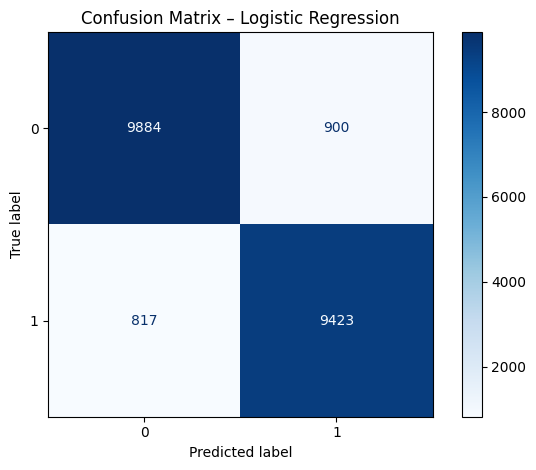

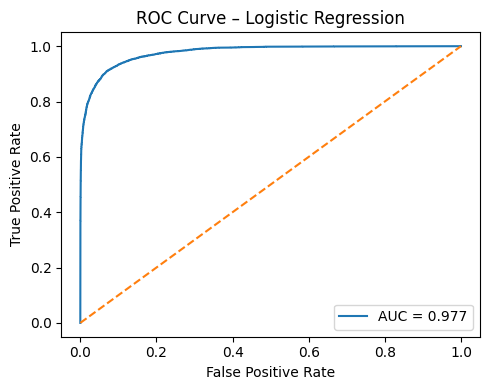


=== Decision Tree ===
Confusion matrix (numbers):
[[9984  800]
 [ 830 9410]]

Classification report:
              precision    recall  f1-score   support

           0      0.923     0.926     0.925     10784
           1      0.922     0.919     0.920     10240

    accuracy                          0.922     21024
   macro avg      0.922     0.922     0.922     21024
weighted avg      0.922     0.922     0.922     21024



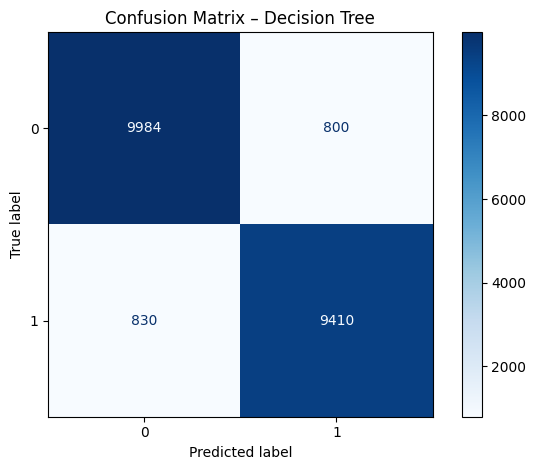

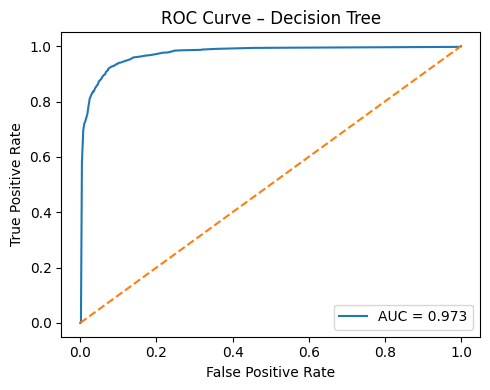


=== Random Forest ===
Confusion matrix (numbers):
[[10138   646]
 [  741  9499]]

Classification report:
              precision    recall  f1-score   support

           0      0.932     0.940     0.936     10784
           1      0.936     0.928     0.932     10240

    accuracy                          0.934     21024
   macro avg      0.934     0.934     0.934     21024
weighted avg      0.934     0.934     0.934     21024



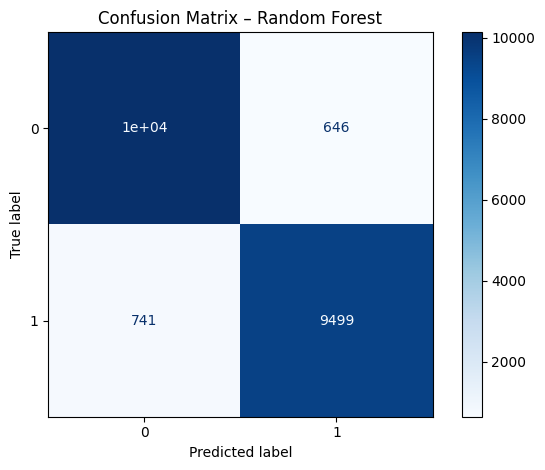

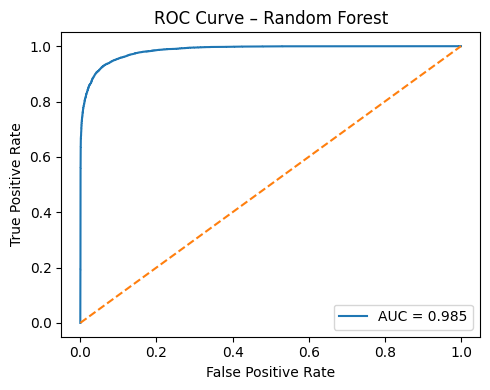

In [26]:
auc_lr = eval_model(logreg, X_test, y_test, "Logistic Regression")
auc_dt = eval_model(tree, X_test, y_test, "Decision Tree")
auc_rf = eval_model(rf, X_test, y_test, "Random Forest")
